In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load and Inspect Data

df=pd.read_csv("indian_movies_500.csv")
print("First 5 Rows")
print(df.head())
print(df.tail())
print(df.info())

First 5 Rows
   Movie_ID          Title   Language   Genre         Director  Release_Year  \
0      1001  Jawan Journey    Kannada  Action   Shoojit Sircar          2006   
1      1002          Super    Bengali  Comedy  Vishal Bhardwaj          2021   
2      1003   Kaithi Uncut    Kannada   Drama       Pritam Das          2005   
3      1004        Pathaan    Kannada   Drama      Karan Johar          2007   
4      1005   Super Empire  Malayalam  Sci-Fi  S. S. Rajamouli          2015   

   Rating  Budget_Crores  BoxOffice_Crores  
0     NaN          125.8             218.0  
1     9.5          215.4             551.4  
2     8.8          442.8             673.9  
3     4.9          124.7            1037.0  
4     6.0          186.1             578.6  
     Movie_ID            Title Language       Genre               Director  \
495      1496        Chhello 9   Telugu      Sci-Fi             Pritam Das   
496      1497  Sairat Rising 3    Hindi     Romance         Prashanth Neel   
49

In [ ]:
# Data Cleaning
print("Missing Value Before Cleaning")
print(df.isnull().sum())
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['BoxOffice_Crores'] = df['BoxOffice_Crores'].fillna(df['BoxOffice_Crores'].mean())
print("Missing values After Cleaning")
print(df.isnull().sum())

Missing Value Before Cleaning
Movie_ID             0
Title                0
Language             0
Genre                0
Director             0
Release_Year         0
Rating              15
Budget_Crores        0
BoxOffice_Crores    10
dtype: int64
Missing values After Cleaning
Movie_ID            0
Title               0
Language            0
Genre               0
Director            0
Release_Year        0
Rating              0
Budget_Crores       0
BoxOffice_Crores    0
dtype: int64


In [ ]:
# Statistical Analysis with NumPy

ratings_arr = df['Rating'].to_numpy()
budget_arr = df['Budget_Crores'].to_numpy()
boxoffice_arr = df['BoxOffice_Crores'].to_numpy()
print(f"Rating Stats -> Mean: {np.mean(ratings_arr):.2f}, Median: {np.median(ratings_arr):.2f}, Std: {np.std(ratings_arr):.2f}")
print(f"Budget_Crores -> Mean: {np.mean(budget_arr):.2f}, Median:{np.median(budget_arr):.2f}, std: {np.std(budget_arr):.2f}")
print(f"BoxOfiice_Crores -> Mean: {np.mean(boxoffice_arr):.2f}, Median:{np.median(boxoffice_arr):.2f}, std: {np.std(boxoffice_arr):.2f}")

Rating Stats -> Mean: 7.13, Median: 7.10, Std: 1.56
Budget_Crores -> Mean: 234.38, Median:244.40, std: 128.06
BoxOfiice_Crores -> Mean: 617.93, Median:617.93, std: 335.37


In [ ]:
# Grouped Analysis with Pandas

lang_ratings = df.groupby('Language')['Rating'].mean().sort_values(ascending=False)
genre_ratings = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
director_ratings = df.groupby('Director')['Rating'].mean().sort_values(ascending=False)
year_rating = df.groupby('Release_Year')['Rating'].mean()
print("Average Ratings")
print(lang_ratings)
print(genre_ratings)
print(director_ratings)
print(year_rating)

Average Ratings
Language
Marathi      7.472973
Kannada      7.465517
Telugu       7.348000
Tamil        7.169767
Punjabi      7.167273
Hindi        7.081667
Malayalam    6.973118
Bengali      6.969492
Gujarati     6.655556
Name: Rating, dtype: float64
Genre
Comedy        7.698113
Romance       7.419608
Sci-Fi        7.379070
Mystery       7.261224
Devotional    7.182000
Crime         7.162745
Historical    7.071154
Action        6.909804
Drama         6.683051
Thriller      6.468293
Name: Rating, dtype: float64
Director
Zoya Akhtar              7.682353
Mani Ratnam              7.457692
Prashanth Neel           7.410714
Chaitanya Tamhane        7.376471
Sanjay Leela Bhansali    7.360000
Shoojit Sircar           7.293333
Ayan Mukerji             7.156250
Vidhu Vinod Chopra       7.154839
Vishal Bhardwaj          7.137500
Anurag Kashyap           7.111538
Atlee                    6.997436
Pritam Das               6.934615
Sukumar                  6.934286
Karan Johar              6.82333

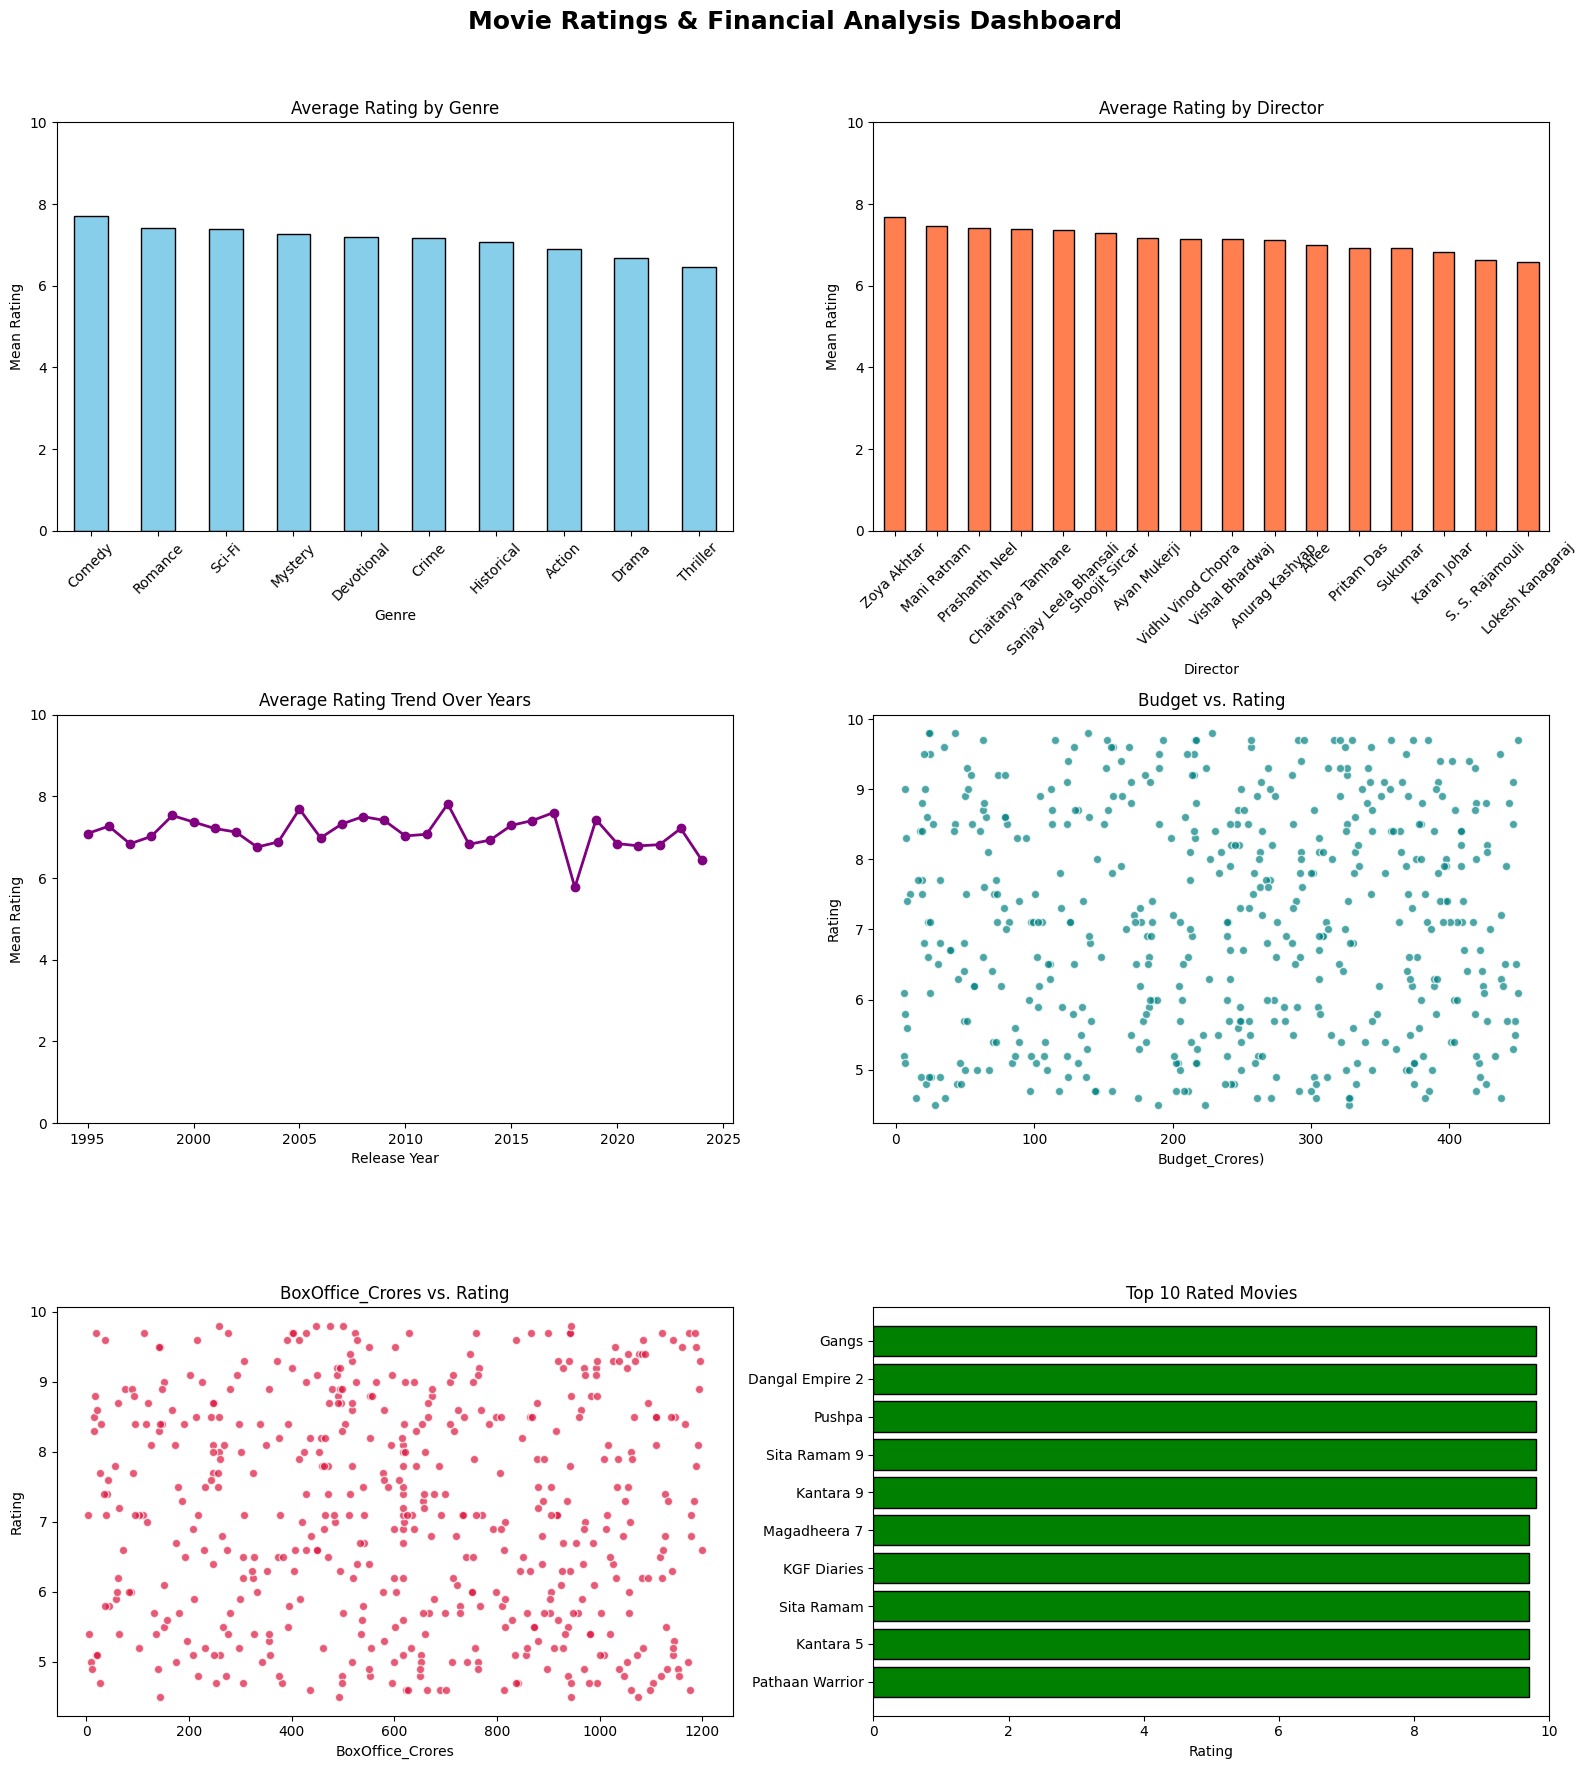

In [ ]:
# Visualizations with Matplotlib

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Movie Ratings & Financial Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. Bar Plot: Average Rating by Genre
genre_ratings.plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Average Rating by Genre', fontsize=12)
axes[0, 0].set_ylabel('Mean Rating')
axes[0, 0].set_ylim(0, 10)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Bar Plot: Average Rating by Director
director_ratings.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Average Rating by Director', fontsize=12)
axes[0, 1].set_ylabel('Mean Rating')
axes[0, 1].set_ylim(0, 10)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Line Plot: Average Ratings over Years
axes[1, 0].plot(year_rating.index, year_rating.values, marker='o', color='purple', linewidth=2)
axes[1, 0].set_title('Average Rating Trend Over Years', fontsize=12)
axes[1, 0].set_xlabel('Release Year')
axes[1, 0].set_ylabel('Mean Rating')
axes[1, 0].set_ylim(0, 10)

# 4. Scatter Plot: Budget vs. Rating
axes[1, 1].scatter(df['Budget_Crores'], df['Rating'], alpha=0.7, color='teal', edgecolors='w')
axes[1, 1].set_title('Budget vs. Rating', fontsize=12)
axes[1, 1].set_xlabel('Budget_Crores)')
axes[1, 1].set_ylabel('Rating')

# 5. Scatter Plot: BoxOffice_Crores(Revenue) vs. Rating
axes[2, 0].scatter(df['BoxOffice_Crores'], df['Rating'], alpha=0.7, color='crimson', edgecolors='w')
axes[2, 0].set_title('BoxOffice_Crores vs. Rating', fontsize=12)
axes[2, 0].set_xlabel('BoxOffice_Crores')
axes[2, 0].set_ylabel('Rating')

# 6. Horizontal Bar Plot: Top 10 Rated Movies
top_10 = df.nlargest(10, 'Rating').sort_values('Rating', ascending=True)
axes[2, 1].barh(top_10['Title'], top_10['Rating'], color='green', edgecolor='black')
axes[2, 1].set_title('Top 10 Rated Movies', fontsize=12)
axes[2, 1].set_xlabel('Rating')
axes[2, 1].set_xlim(0, 10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# print(df.describe())
# print(df.info())
print(df.columns)

Index(['Movie_ID', 'Title', 'Language', 'Genre', 'Director', 'Release_Year',
       'Rating', 'Budget_Crores', 'BoxOffice_Crores'],
      dtype='object')


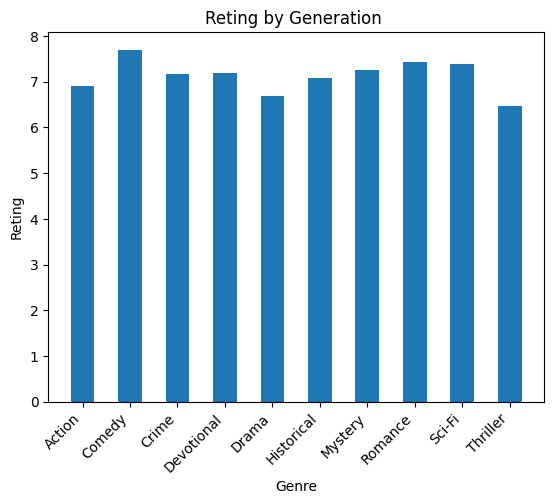

In [ ]:
# plt.plot(kind = 'line', color="red", marker='o')
genre_rating = df.groupby("Genre")["Rating"].mean()
plt.bar(genre_rating.index, genre_rating.values, width = 0.5)

plt.title("Reting by Generation ")
plt.xlabel("Genre")
plt.ylabel("Reting")
plt.xticks(rotation=45, ha="right")
plt.show()

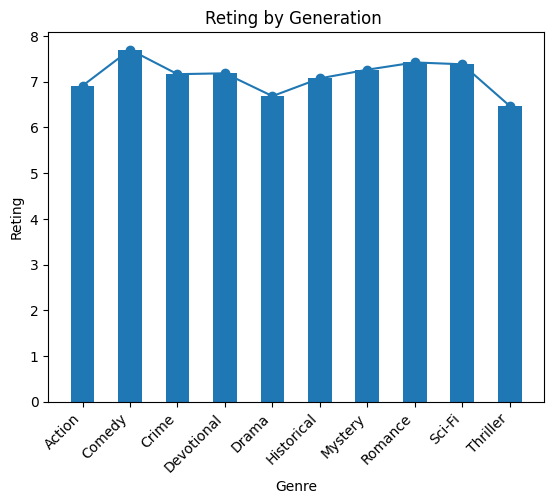

In [ ]:
genre_rating = df.groupby("Genre")["Rating"].mean()
plt.bar(genre_rating.index, genre_rating.values, width = 0.5)
genre_rating.plot(kind="line", marker = 'o')
plt.title("Reting by Generation ")
plt.xlabel("Genre")
plt.ylabel("Reting")
plt.xticks(rotation=45, ha="right")
plt.show()